In [1]:
import cotengra as ctg
import numpy as np
import quimb.tensor as qtn
import quimb as qu
import tqdm
import matplotlib.pyplot as plt
from skopt import Optimizer
from skopt.plots import plot_convergence, plot_objective

In [2]:
seed = 10

In [3]:
opt = ctg.ReusableHyperOptimizer(
    methods=['greedy'],
    reconf_opts={}, 
    max_repeats=32,
    max_time="rate:1e6",
    parallel=True,
    minimize='combo-64',
    # use the following for persistently cached paths
    directory=True,
)

In [4]:
def Q_to_Ising(Q, offset):
    n_qubits = Q.shape[0]
    J = {(i, j) : 0 for i in range(n_qubits) for j in range(i, n_qubits)}

    for i in range(n_qubits):
        # Update the magnetic field for qubit i based on its diagonal element in Q
        J[(i, i)] -= Q[i, i] / 2
        # Update the offset based on the diagonal element in Q
        offset += Q[i, i] / 2
        # Calculate pairwise interactions
        for j in range(i + 1, n_qubits):
            # Update the pairwise interaction strength (J) between qubits i and j
            J[(i, j)] += Q[i, j] / 4
            # Update the magnetic fields for qubits i and j based on their interactions in Q
            J[(i, i)] -= Q[i, j] / 4
            J[(j, j)] -= Q[i, j] / 4
            # Update the offset based on the interaction strength between qubits i and j
            offset += Q[i, j] / 4
    return J, offset

In [10]:
data = np.load('../../qubo_solvers/out/tangle/qubo_data_test.npy', allow_pickle=True)
Q, offset, W = data
# Move terms to upper triangular part
Q = np.triu(Q) * 2
Q -= np.triu(np.triu(Q).T) / 2
N_vars = Q.shape[0]

# Get Hamiltonian terms
terms, offset = Q_to_Ising(Q, 0)

In [6]:
rng = np.random.default_rng(seed)
Q = rng.random((4, 4))
Q = (Q + Q.T) / 2
# Q = np.triu(Q, +1) + np.tril(Q, -1)
N_vars = Q.shape[0]

# Get Hamiltonian terms
terms, offset = Q_to_Ising(Q, 0)

In [11]:
p = 2
gammas = qu.randn(p, seed=seed)
betas = qu.randn(p, seed=seed)

In [12]:
# Self-interactions break this
# Local install source code, add a loop over diagonal with rz gate
circ_ex = qtn.circ_qaoa(terms, p, gammas, betas)

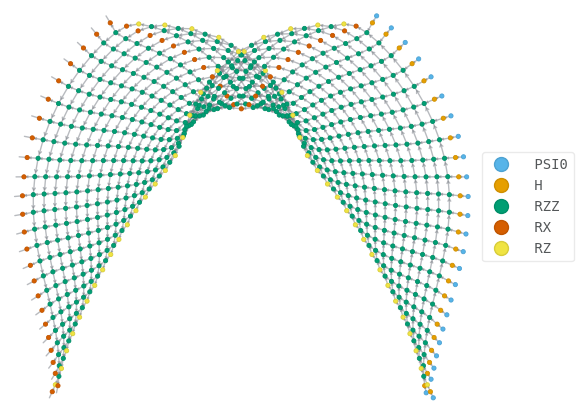

In [13]:
circ_ex.psi.draw(color=['PSI0', 'H', 'RZZ', 'RX', 'RZ'])

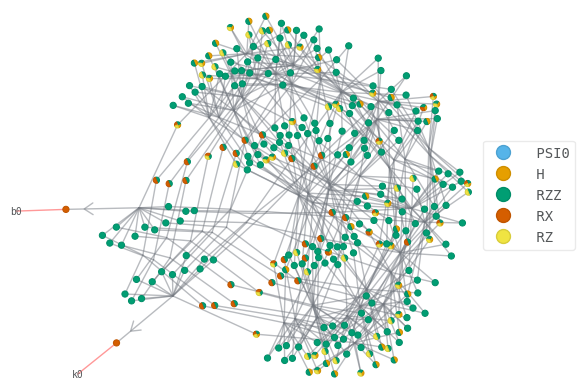

In [14]:
circ_ex.get_rdm_lightcone_simplified([0]).draw(color=['PSI0', 'H', 'RZZ', 'RX', 'RZ'], highlight_inds=['k0', 'b0'])

In [ ]:
ZZ = qu.pauli('Z') & qu.pauli('Z')

local_exp_rehs = [
    circ_ex.local_expectation_rehearse(weight * ZZ, edge, optimize=opt)
    for edge, weight in tqdm.tqdm(list(terms.items()))
]

In [ ]:
with plt.style.context(qu.NEUTRAL_STYLE):
    fig, ax1 = plt.subplots()
    ax1.plot([rehs['W'] for rehs in local_exp_rehs], color='green')
    ax1.set_ylabel('contraction width, $W$, [log2]', color='green')
    ax1.tick_params(axis='y', labelcolor='green')

    ax2 = ax1.twinx()
    ax2.plot([rehs['C'] for rehs in local_exp_rehs], color='orange')
    ax2.set_ylabel('contraction cost, $C$, [log10]', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

In [ ]:
def energy(x):
    p = len(x) // 2
    gammas = x[:p]
    betas = x[p:]
    circ = qtn.circ_qaoa(terms, p, gammas, betas)

    Z = qu.pauli('Z')
    ZZ = qu.pauli('Z') & qu.pauli('Z')

    ens = [
        circ.local_expectation(weight * ZZ, edge, optimize=opt, backend="jax")
        if not edge[0] == edge[1]
        else circ.local_expectation(weight * Z, edge[0], optimize=opt, backend="jax")
        for edge, weight in terms.items()
    ]
    
    return sum(ens).real

In [ ]:
eps = 1e-6
bounds = (
    [(0.0        + eps, qu.pi / 2 - eps)] * p + 
    [(-qu.pi / 4 + eps, qu.pi / 4 - eps)] * p
)

bopt = Optimizer(bounds)

In [ ]:
for i in tqdm.trange(100):
    x = bopt.ask()
    res = bopt.tell(x, energy(x))

In [ ]:
with plt.style.context(qu.NEUTRAL_STYLE):
    plot_convergence(res)

In [ ]:
with plt.style.context(qu.NEUTRAL_STYLE):
    plot_objective(
        res, 
        cmap='RdYlBu_r',
        dimensions=[f'$\\gamma_{i}$' for i in range(p)] + [f'$\\beta_{i}$' for i in range(p)],
    )